# Bioinformatics Pipeline

## Install & import packages

In [ ]:
import google.colab.files as files
from pathlib import Path

### Input or fetch data

In [ ]:
# Upload a FASTA file(s)
uploaded = files.upload()

# Process the uploaded files
for filename in uploaded.keys():
    print(f'Uploaded file: {filename}')
    # You can now read and process the file content, for example:
    # with open(Path(filename).resolve(), 'r') as f:
    #     fasta_content = f.read()
    #     print(f"Content of {filename}:\n{fasta_content[:200]}...") # Print first 200 chars


Saving YP_498670.1 SAOUHSC_00069.faa.txt to YP_498670.1 SAOUHSC_00069.faa.txt
Saving YP_500469.1 SAOUHSC_01972.faa.txt to YP_500469.1 SAOUHSC_01972.faa.txt
Uploaded file: YP_498670.1 SAOUHSC_00069.faa.txt
Uploaded file: YP_500469.1 SAOUHSC_01972.faa.txt


##Store FASTA File

In [ ]:
# Extract the filename(s) from the uploaded dictionary
fasta_files = list(uploaded.keys())

fasta_data_dict = {}

if fasta_files:
    print(f"Found {len(fasta_files)} FASTA file(s) for analysis.")

    # Read the content of all files into a dictionary
    for file_path in fasta_files:
        with open(file_path, 'r') as f:
            fasta_data_dict[file_path] = f.read()
        print(f"Successfully loaded {len(fasta_data_dict[file_path])} characters from {file_path}.")
else:
    print("No files were uploaded in the previous step. Please run the upload cell first.")


Found 2 FASTA file(s) for analysis.
Successfully loaded 625 characters from YP_498670.1 SAOUHSC_00069.faa.txt.
Successfully loaded 426 characters from YP_500469.1 SAOUHSC_01972.faa.txt.


## Calculate Psychochemical Properties

In [ ]:
!pip install biopython

In [ ]:
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis
import io

if 'fasta_data_dict' in locals() and fasta_data_dict:
    for filename, fasta_data in fasta_data_dict.items():
        print(f"\n{'='*50}\nProcessing File: {filename}\n{'='*50}")
        # Read the FASTA data from the stored variable
        records = list(SeqIO.parse(io.StringIO(fasta_data), 'fasta'))

        for record in records:
            print(f"\n--- Physiochemical Properties for: {record.id} ---")

            # Convert sequence to string and remove stop codons if present
            sequence = str(record.seq).replace('*', '')

            # Initialize ProteinAnalysis object
            analyzed_seq = ProteinAnalysis(sequence)

            # 1. Amino acid length
            print(f"Length: {len(sequence)} amino acids")

            # 2. Molecular weight
            mw = analyzed_seq.molecular_weight()
            print(f"Molecular Weight: {mw:.2f} Da")

            # 3. Amino acid composition
            aa_comp = analyzed_seq.count_amino_acids()
            print("Amino Acid Composition:")
            for aa, count in aa_comp.items():
                print(f"  {aa}: {count}")

            # 4. Isoelectric point
            pi = analyzed_seq.isoelectric_point()
            print(f"Isoelectric Point (pI): {pi:.2f}")

            # 5. Net charge at physiological pH (7.0)
            charge = analyzed_seq.charge_at_pH(7.0)
            print(f"Net Charge (at pH 7.0): {charge:.2f}")

            # 6. Extinction coefficient
            # Returns a tuple: (reduced Cys, oxidized Cys forming disulfide bridges)
            ext_coeff = analyzed_seq.molar_extinction_coefficient()
            print(f"Extinction Coefficient (reduced / oxidized): {ext_coeff[0]} / {ext_coeff[1]} M^-1 cm^-1")
else:
    print("No FASTA data found. Please run the upload and storage cells first.")



Processing File: YP_498670.1 SAOUHSC_00069.faa.txt

--- Physiochemical Properties for: YP_498670.1 ---
Length: 516 amino acids
Molecular Weight: 56436.49 Da
Amino Acid Composition:
  A: 50
  C: 0
  D: 39
  E: 41
  F: 16
  G: 38
  H: 5
  I: 18
  K: 63
  L: 42
  M: 5
  N: 66
  P: 32
  Q: 37
  R: 9
  S: 24
  T: 11
  V: 14
  W: 0
  Y: 6
Isoelectric Point (pI): 5.54
Net Charge (at pH 7.0): -7.97
Extinction Coefficient (reduced / oxidized): 8940 / 8940 M^-1 cm^-1

Processing File: YP_500469.1 SAOUHSC_01972.faa.txt

--- Physiochemical Properties for: YP_500469.1 ---
Length: 320 amino acids
Molecular Weight: 35637.32 Da
Amino Acid Composition:
  A: 23
  C: 1
  D: 31
  E: 25
  F: 8
  G: 20
  H: 3
  I: 19
  K: 62
  L: 26
  M: 7
  N: 10
  P: 5
  Q: 17
  R: 2
  S: 25
  T: 12
  V: 16
  W: 0
  Y: 8
Isoelectric Point (pI): 9.01
Net Charge (at pH 7.0): 7.79
Extinction Coefficient (reduced / oxidized): 11920 / 11920 M^-1 cm^-1


##Create a Property Dictionary

In [ ]:
import pandas as pd

protein_properties = []

if 'fasta_data_dict' in locals() and fasta_data_dict:
    for filename, fasta_data in fasta_data_dict.items():
        records = list(SeqIO.parse(io.StringIO(fasta_data), 'fasta'))
        for record in records:
            sequence = str(record.seq).replace('*', '')
            analyzed_seq = ProteinAnalysis(sequence)

            # Create a dictionary for the current protein
            prop_dict = {
                'Protein_ID': record.id,
                'Length': len(sequence),
                'Molecular_Weight_Da': round(analyzed_seq.molecular_weight(), 2),
                'Isoelectric_Point': round(analyzed_seq.isoelectric_point(), 2),
                'Net_Charge_pH7': round(analyzed_seq.charge_at_pH(7.0), 2),
                'Extinction_Coeff_Reduced': analyzed_seq.molar_extinction_coefficient()[0]
            }
            protein_properties.append(prop_dict)

    # Convert the list of dictionaries into a pandas DataFrame
    properties_df = pd.DataFrame(protein_properties)
    print("Protein Properties Summary:")
    display(properties_df)
else:
    print("No FASTA data found to create the dictionary.")


Protein Properties Summary:


,Protein_ID,Length,Molecular_Weight_Da,Isoelectric_Point,Net_Charge_pH7,Extinction_Coeff_Reduced
0,YP_498670.1,516,56436.49,5.54,-7.97,8940
1,YP_500469.1,320,35637.32,9.01,7.79,11920


##Sequence Similarity

In [ ]:
from Bio import Align
from Bio import SeqIO
import io
import itertools

sequences = {}

# Extract all sequences and their IDs
if 'fasta_data_dict' in locals() and fasta_data_dict:
    for filename, fasta_data in fasta_data_dict.items():
        records = list(SeqIO.parse(io.StringIO(fasta_data), 'fasta'))
        for record in records:
            sequence = str(record.seq).replace('*', '')
            sequences[record.id] = sequence

    # Check if we have at least 2 sequences to compare
    if len(sequences) < 2:
        print("Need at least 2 sequences to calculate similarity. Please upload more files.")
    else:
        print(f"Calculating pairwise similarities for {len(sequences)} sequences...\n")

        # Initialize the aligner
        aligner = Align.PairwiseAligner()
        aligner.mode = 'global' # Using global alignment

        # Generate all unique pairs of sequences
        pairs = list(itertools.combinations(sequences.keys(), 2))

        for id1, id2 in pairs:
            seq1 = sequences[id1]
            seq2 = sequences[id2]

            # Perform the alignment
            alignments = aligner.align(seq1, seq2)
            best_alignment = alignments[0]

            # Calculate a basic similarity percentage based on the alignment score and max length
            max_len = max(len(seq1), len(seq2))
            similarity_score = (best_alignment.score / max_len) * 100

            print(f"Alignment between {id1} and {id2}:")
            print(f"  Similarity Score: {similarity_score:.2f}%")
            print(f"  Raw Score: {best_alignment.score}")
            print("-" * 40)
else:
    print("No FASTA data found. Please run the previous storage cells first.")


Calculating pairwise similarities for 2 sequences...

Alignment between YP_498670.1 and YP_500469.1:
  Similarity Score: -12.21%
  Raw Score: -63.0
----------------------------------------


###Store Sequence Similarity

In [ ]:
import pandas as pd

similarity_results = []

if 'sequences' in locals() and len(sequences) >= 2:
    # Re-initialize the aligner to regenerate the scores for storage
    aligner = Align.PairwiseAligner()
    aligner.mode = 'global'

    pairs = list(itertools.combinations(sequences.keys(), 2))

    for id1, id2 in pairs:
        seq1 = sequences[id1]
        seq2 = sequences[id2]

        alignments = aligner.align(seq1, seq2)
        best_alignment = alignments[0]

        max_len = max(len(seq1), len(seq2))
        similarity_score = (best_alignment.score / max_len) * 100

        # Append the results to our list
        similarity_results.append({
            'Protein_1': id1,
            'Protein_2': id2,
            'Raw_Score': best_alignment.score,
            'Similarity_Percentage': round(similarity_score, 2)
        })

    # Create a DataFrame from the results
    similarity_df = pd.DataFrame(similarity_results)

    print("Sequence Similarity Summary:")
    display(similarity_df)

    print("\n" + "="*50)
    print("--- Explanation of Similarity Scores ---")
    print("="*50)
    print("1. Raw Score:")
    print("   This is the absolute score calculated by Biopython's PairwiseAligner.")
    print("   Points are added for matching amino acids, and subtracted for mismatches or gaps.")
    print("   A negative score (like -63.0) means the penalty for mismatches and gaps heavily")
    print("   outweighed the positive matches, indicating the sequences are highly divergent.")
    print("\n2. Similarity Percentage:")
    print("   This is a normalized metric created by dividing the Raw Score by the length of")
    print("   the longer sequence. While a true percentage of identity would be between 0-100%,")
    print("   this metric can be negative if the Raw Score is negative.")
else:
    print("Not enough sequences found to store similarity data. Please run the alignment cell first.")


Sequence Similarity Summary:


,Protein_1,Protein_2,Raw_Score,Similarity_Percentage
0,YP_498670.1,YP_500469.1,-63.0,-12.21



--- Explanation of Similarity Scores ---
1. Raw Score:
   This is the absolute score calculated by Biopython's PairwiseAligner.
   Points are added for matching amino acids, and subtracted for mismatches or gaps.
   A negative score (like -63.0) means the penalty for mismatches and gaps heavily
   outweighed the positive matches, indicating the sequences are highly divergent.

2. Similarity Percentage:
   This is a normalized metric created by dividing the Raw Score by the length of
   the longer sequence. While a true percentage of identity would be between 0-100%,
   this metric can be negative if the Raw Score is negative.


## Relationship Between Proteins

### Dendogram

Generating dendrogram for 2 proteins...



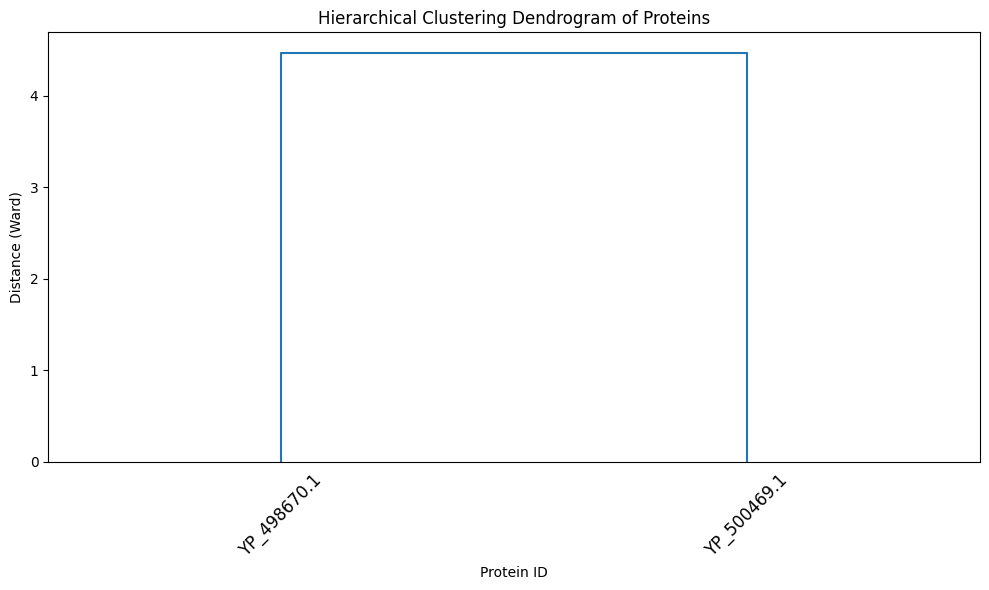


--- Dendrogram Explanation ---
The dendrogram visually represents the relationships between proteins based on
their physiochemical properties. Proteins that join together at lower heights (y-axis)
are more similar to each other. We standardized the data so properties with large numbers
(like Molecular Weight) don't unfairly outweigh properties with small numbers (like Net Charge).


In [ ]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import StandardScaler
import numpy as np

if 'properties_df' in locals() and not properties_df.empty:
    if len(properties_df) < 2:
        print("Need at least 2 proteins to generate a dendrogram.")
    else:
        print(f"Generating dendrogram for {len(properties_df)} proteins...\n")

        # Select the numerical features for clustering
        features = ['Length', 'Molecular_Weight_Da', 'Isoelectric_Point', 'Net_Charge_pH7', 'Extinction_Coeff_Reduced']
        clustering_data = properties_df.set_index('Protein_ID')[features]

        # Standardize the features so each property contributes equally to the distance
        scaler = StandardScaler()
        scaled_features = scaler.fit_transform(clustering_data)

        # Perform hierarchical clustering using Ward's method
        # Ward minimizes the variance of the clusters being merged
        Z = linkage(scaled_features, method='ward')

        # Plot the dendrogram
        plt.figure(figsize=(10, 6))
        plt.title('Hierarchical Clustering Dendrogram of Proteins')
        plt.xlabel('Protein ID')
        plt.ylabel('Distance (Ward)')

        dendrogram(
            Z,
            labels=clustering_data.index.tolist(),
            leaf_rotation=45.,
            leaf_font_size=12.,
            show_contracted=True
        )

        plt.tight_layout()
        plt.show()

        print("\n--- Dendrogram Explanation ---")
        print("The dendrogram visually represents the relationships between proteins based on")
        print("their physiochemical properties. Proteins that join together at lower heights (y-axis)")
        print("are more similar to each other. We standardized the data so properties with large numbers")
        print("(like Molecular Weight) don't unfairly outweigh properties with small numbers (like Net Charge).")
else:
    print("Properties data not found. Please run the 'Create a Property Dictionary' cell first.")


### Relationship Outputs

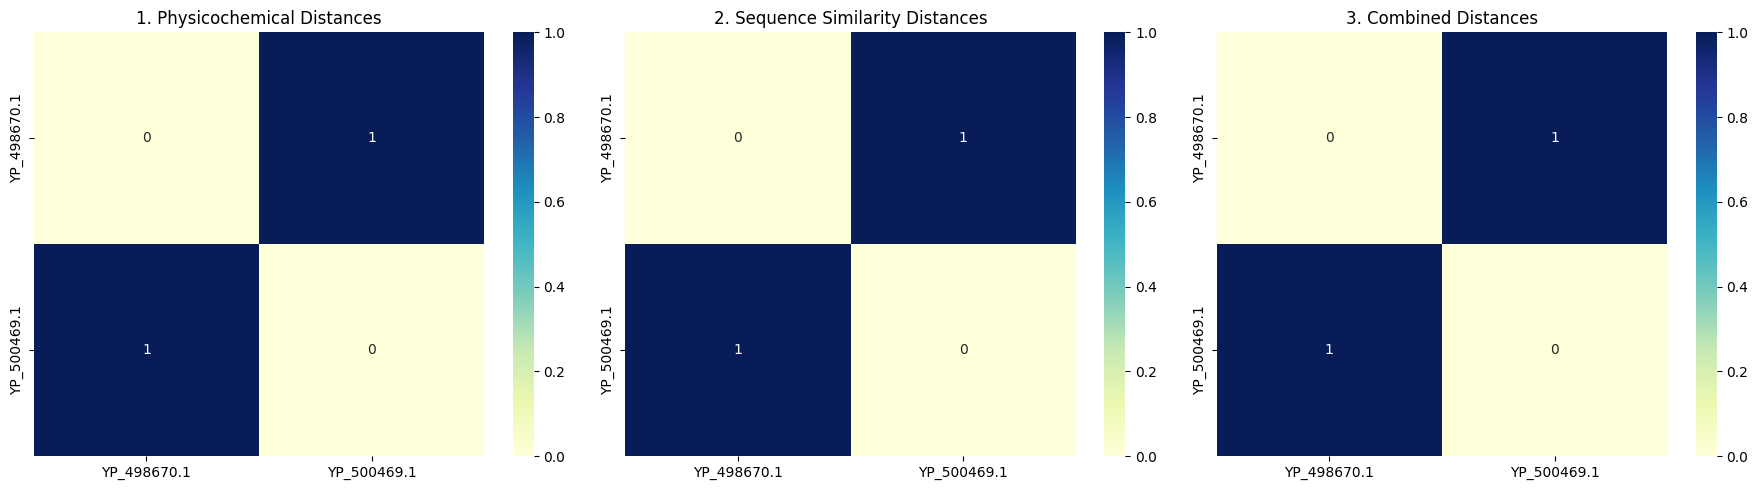


--- Relationship Heatmaps Explanation ---
These heatmaps show the pairwise 'distances' (dissimilarity) between proteins on a 0 to 1 scale.
0 (lighter color) means identical/highly similar, and 1 (darker color) means highly dissimilar.
1. Physicochemical: Distance based on properties like molecular weight, pI, and charge.
2. Sequence Similarity: Distance mathematically derived from your alignment scores.
3. Combined: The average of the physicochemical and sequence distances.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler, MinMaxScaler

if 'properties_df' in locals() and 'similarity_df' in locals() and len(properties_df) >= 2:
    protein_ids = properties_df['Protein_ID'].tolist()

    # 1. Physicochemical Distance Matrix
    features = ['Length', 'Molecular_Weight_Da', 'Isoelectric_Point', 'Net_Charge_pH7', 'Extinction_Coeff_Reduced']
    clustering_data = properties_df.set_index('Protein_ID')[features]

    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(clustering_data)

    # Calculate pairwise euclidean distances and convert to square matrix
    phys_dist_array = pdist(scaled_features, metric='euclidean')
    phys_dist_matrix = squareform(phys_dist_array)

    # Normalize to 0-1 for combining later
    mm_scaler = MinMaxScaler()
    phys_dist_norm = mm_scaler.fit_transform(phys_dist_matrix)

    # 2. Sequence Similarity Distance Matrix
    # Initialize with high similarity for identical proteins (diagonal)
    seq_sim_matrix = pd.DataFrame(100.0, index=protein_ids, columns=protein_ids)
    for _, row in similarity_df.iterrows():
        p1, p2, sim = row['Protein_1'], row['Protein_2'], row['Similarity_Percentage']
        seq_sim_matrix.loc[p1, p2] = sim
        seq_sim_matrix.loc[p2, p1] = sim

    # Convert similarity to distance
    max_sim = seq_sim_matrix.values.max()
    seq_dist_matrix = max_sim - seq_sim_matrix.values

    # Normalize to 0-1
    seq_dist_norm = mm_scaler.fit_transform(seq_dist_matrix)

    # 3. Combined Distance Matrix
    combined_dist_norm = (phys_dist_norm + seq_dist_norm) / 2.0

    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.heatmap(phys_dist_norm, xticklabels=protein_ids, yticklabels=protein_ids, ax=axes[0], cmap='YlGnBu', annot=True)
    axes[0].set_title('1. Physicochemical Distances')

    sns.heatmap(seq_dist_norm, xticklabels=protein_ids, yticklabels=protein_ids, ax=axes[1], cmap='YlGnBu', annot=True)
    axes[1].set_title('2. Sequence Similarity Distances')

    sns.heatmap(combined_dist_norm, xticklabels=protein_ids, yticklabels=protein_ids, ax=axes[2], cmap='YlGnBu', annot=True)
    axes[2].set_title('3. Combined Distances')

    plt.tight_layout()
    plt.show()

    print("\n--- Relationship Heatmaps Explanation ---")
    print("These heatmaps show the pairwise 'distances' (dissimilarity) between proteins on a 0 to 1 scale.")
    print("0 (lighter color) means identical/highly similar, and 1 (darker color) means highly dissimilar.")
    print("1. Physicochemical: Distance based on properties like molecular weight, pI, and charge.")
    print("2. Sequence Similarity: Distance mathematically derived from your alignment scores.")
    print("3. Combined: The average of the physicochemical and sequence distances.")
else:
    print("Required data not found. Please ensure you have run both the property dictionary and sequence similarity cells.")
